# Getting Started: Bond Scan for H2

This notebook performs a simple **bond-length scan** for the hydrogen molecule
**H2** using **VQE**.

Goals:

- define a range of H-H distances
- run VQE at each geometry
- build an energy curve
- identify the minimum-energy bond length in the scanned range

This is one of the most standard small quantum chemistry workflows.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from vqe.core import run_vqe

## Why a bond scan?

A molecule does not have a single arbitrary geometry. Its energy depends on the
nuclear coordinates.

For a diatomic molecule like `H2`, the simplest structural study is to vary the
bond length and compute the energy at each point:

$$
E = E(R)
$$

The minimum of this curve gives the lowest-energy bond length within the chosen
model and basis.

## Distance grid

We choose a small range of H-H distances in angstrom.

In [2]:
distances = np.linspace(0.40, 1.60, 13)
distances

array([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6])

## VQE settings

We keep the algorithm settings fixed across the scan so that the geometry is
the only changing variable.

In [3]:
ansatz_name = "UCCSD"
optimizer_name = "Adam"
steps = 60
seed = 0
basis = "sto-3g"
charge = 0
unit = "angstrom"

## Run the scan

For each bond length `R`, we construct an explicit geometry:

- first H at `(0, 0, 0)`
- second H at `(R, 0, 0)`

Then we run `VQE` and store the final energy.

In [4]:
energies = []
results = []

for R in distances:
    symbols = ["H", "H"]
    coordinates = np.array(
        [
            [0.0, 0.0, 0.0],
            [R, 0.0, 0.0],
        ],
        dtype=float,
    )

    res = run_vqe(
        molecule=None,
        symbols=symbols,
        coordinates=coordinates,
        basis=basis,
        charge=charge,
        unit=unit,
        ansatz_name=ansatz_name,
        optimizer_name=optimizer_name,
        steps=steps,
        seed=seed,
        noisy=False,
        force=True,
        plot=False,
    )

    energy = float(res["energy"])

    energies.append(energy)
    results.append(
        {
            "distance": float(R),
            "energy": energy,
            "result": res,
        }
    )

    print(f"R = {R:.2f} {unit:8s} -> E = {energy:.10f} Ha")

Step 01/60: E = -0.904361 Ha
Step 02/60: E = -0.909585 Ha
Step 03/60: E = -0.906101 Ha
Step 04/60: E = -0.899949 Ha
Step 05/60: E = -0.913271 Ha
Step 06/60: E = -0.903066 Ha
Step 07/60: E = -0.900477 Ha
Step 08/60: E = -0.908971 Ha
Step 09/60: E = -0.914134 Ha
Step 10/60: E = -0.909814 Ha
Step 11/60: E = -0.905660 Ha
Step 12/60: E = -0.908804 Ha
Step 13/60: E = -0.913471 Ha
Step 14/60: E = -0.913472 Ha
Step 15/60: E = -0.910315 Ha
Step 16/60: E = -0.909211 Ha
Step 17/60: E = -0.911444 Ha
Step 18/60: E = -0.913888 Ha
Step 19/60: E = -0.913609 Ha
Step 20/60: E = -0.911639 Ha
Step 21/60: E = -0.911241 Ha
Step 22/60: E = -0.912889 Ha
Step 23/60: E = -0.914122 Ha
Step 24/60: E = -0.913526 Ha
Step 25/60: E = -0.912408 Ha
Step 26/60: E = -0.912496 Ha
Step 27/60: E = -0.913580 Ha
Step 28/60: E = -0.914134 Ha
Step 29/60: E = -0.913567 Ha
Step 30/60: E = -0.912976 Ha
Step 31/60: E = -0.913325 Ha
Step 32/60: E = -0.914011 Ha
Step 33/60: E = -0.914038 Ha
Step 34/60: E = -0.913563 Ha
Step 35/60: E 

In [5]:
energies = np.asarray(energies, dtype=float)
energies

array([-0.91410202, -1.05511613, -1.11624722, -1.13617506, -1.13413635,
       -1.12052997, -1.10108308, -1.07917328, -1.05671042, -1.03511268,
       -1.01544212, -0.99808653, -0.98335499])

## Minimum on the scanned grid

In [6]:
imin = int(np.argmin(energies))
best_distance = float(distances[imin])
best_energy = float(energies[imin])

print(f"Lowest scanned energy : {best_energy:.10f} Ha")
print(f"Best scanned distance : {best_distance:.6f} {unit}")

Lowest scanned energy : -1.1361750583 Ha
Best scanned distance : 0.700000 angstrom


## Energy curve

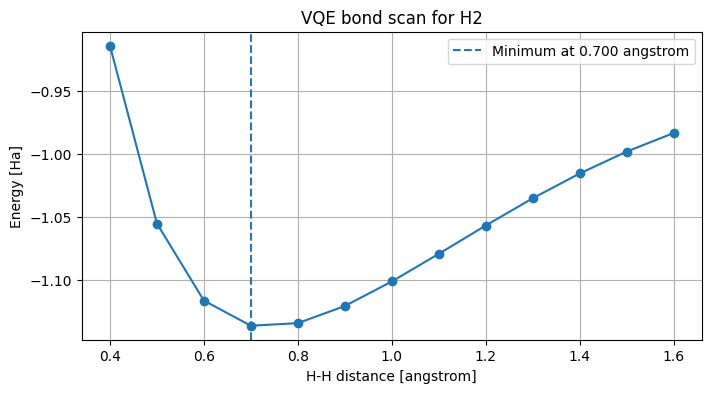

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(distances, energies, marker="o")
plt.axvline(best_distance, linestyle="--", label=f"Minimum at {best_distance:.3f} {unit}")
plt.xlabel(f"H-H distance [{unit}]")
plt.ylabel("Energy [Ha]")
plt.title("VQE bond scan for H2")
plt.grid(True)
plt.legend()
plt.show()

## Inspect the lowest-energy geometry

In [8]:
best_geometry = np.array(
    [
        [0.0, 0.0, 0.0],
        [best_distance, 0.0, 0.0],
    ],
    dtype=float,
)

print("Best geometry:")
print(best_geometry)

Best geometry:
[[0.  0.  0. ]
 [0.7 0.  0. ]]


## Compare optimization traces for a few representative distances

It is often useful to inspect not only the final energies, but also how the
optimizer behaved at different geometries.

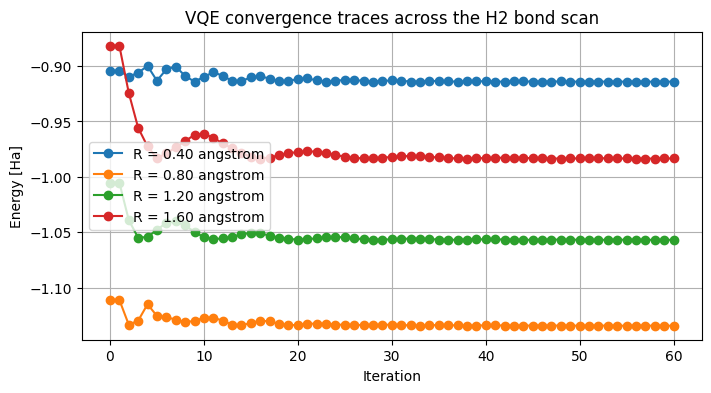

In [9]:
sample_distances = [0.40, 0.80, 1.20, 1.60]
sample_indices = [int(np.argmin(np.abs(distances - d))) for d in sample_distances]

plt.figure(figsize=(8, 4))
for idx in sample_indices:
    R = float(results[idx]["distance"])
    trace = np.asarray(results[idx]["result"]["energies"], dtype=float)
    plt.plot(np.arange(len(trace)), trace, marker="o", label=f"R = {R:.2f} {unit}")

plt.xlabel("Iteration")
plt.ylabel("Energy [Ha]")
plt.title("VQE convergence traces across the H2 bond scan")
plt.grid(True)
plt.legend()
plt.show()

## Tabulated scan results

In [10]:
print(f"{'Distance [' + unit + ']':<18} {'Final energy [Ha]':>20}")
print("-" * 40)
for R, E in zip(distances, energies):
    print(f"{R:<18.6f} {E:>20.10f}")

Distance [angstrom]    Final energy [Ha]
----------------------------------------
0.400000                  -0.9141020244
0.500000                  -1.0551161334
0.600000                  -1.1162472248
0.700000                  -1.1361750583
0.800000                  -1.1341363499
0.900000                  -1.1205299745
1.000000                  -1.1010830777
1.100000                  -1.0791732824
1.200000                  -1.0567104211
1.300000                  -1.0351126820
1.400000                  -1.0154421211
1.500000                  -0.9980865333
1.600000                  -0.9833549937


## Interpretation

The energy is high at very short bond lengths because the nuclei are too close.
As the bond is stretched from that regime, the energy decreases toward a
minimum. If the bond is stretched too far, the energy rises again.

This is the basic shape of a molecular potential-energy curve.

## What this notebook showed

We:

- defined a grid of H-H distances
- ran `VQE` at each geometry
- built an energy curve
- identified the lowest-energy bond length on the scan
- compared convergence traces at several distances

This is the basic bond-scan workflow in the repository.